In [28]:
##Can take some minutes importing the libraries the first time
import time
start = time.time()
import os

import re

start = time.time()
import pandas as pd
print(f"Tiempo de import: {time.time() - start:.4f} segundos")
import numpy as np

import matplotlib.pyplot as plt
start = time.time()
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from scipy import stats


from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
print(f"Tiempo de import: {time.time() - start:.4f} segundos")

Tiempo de import: 0.0001 segundos
Tiempo de import: 0.0002 segundos


In [29]:
df = pd.read_csv("../data/Customer-Churn-Records.csv",sep=",")
##Remove unecesary data
df=df.drop(columns=["RowNumber","CustomerId","Surname"])
##During first training was observed a so high correlation between Complain and Exited
df=df.drop(columns=["Complain"])
df.tail()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0,1,DIAMOND,300
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,5,PLATINUM,771
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1,3,SILVER,564
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,2,GOLD,339
9999,792,France,Female,28,4,130142.79,1,1,0,38190.78,0,3,DIAMOND,911


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CreditScore         10000 non-null  int64  
 1   Geography           10000 non-null  str    
 2   Gender              10000 non-null  str    
 3   Age                 10000 non-null  int64  
 4   Tenure              10000 non-null  int64  
 5   Balance             10000 non-null  float64
 6   NumOfProducts       10000 non-null  int64  
 7   HasCrCard           10000 non-null  int64  
 8   IsActiveMember      10000 non-null  int64  
 9   EstimatedSalary     10000 non-null  float64
 10  Exited              10000 non-null  int64  
 11  Satisfaction Score  10000 non-null  int64  
 12  Card Type           10000 non-null  str    
 13  Point Earned        10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [31]:
df["Card Type"].unique()

<StringArray>
['DIAMOND', 'GOLD', 'SILVER', 'PLATINUM']
Length: 4, dtype: str

In [32]:
def change_card_type(cardType):
    catalog={
        "DIAMOND":3,
        "PLATINUM":2,
        "GOLD":1,
        "SILVER":0
    }
    return catalog[cardType]
df["Card Type"] = df["Card Type"].apply(change_card_type)

In [33]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,3.013800,1.501300,606.515100
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,1.405919,1.118357,225.924839
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,1.000000,0.000000,119.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,2.000000,1.000000,410.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,3.000000,2.000000,605.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,4.000000,3.000000,801.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,5.000000,3.000000,1000.000000


In [34]:
print(df.keys())

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'Satisfaction Score', 'Card Type', 'Point Earned'],
      dtype='str')


In [35]:
#Search outliers
for key in df.keys():
    try: 
        Q1 = df[key].quantile(0.25)
        Q3 = df[key].quantile(0.75)
        
        IQR = Q3 - Q1
        
        inferior = Q1 - 1.5 * IQR
        superior = Q3 + 1.5 * IQR
        
        outliers = df[(df[key] < inferior) | (df[key] > superior)]
        if (len(outliers) !=0):
            print(f"{key} -> {len(outliers)}")
    except:
        pass


CreditScore -> 15
Age -> 359
NumOfProducts -> 60
Exited -> 2038


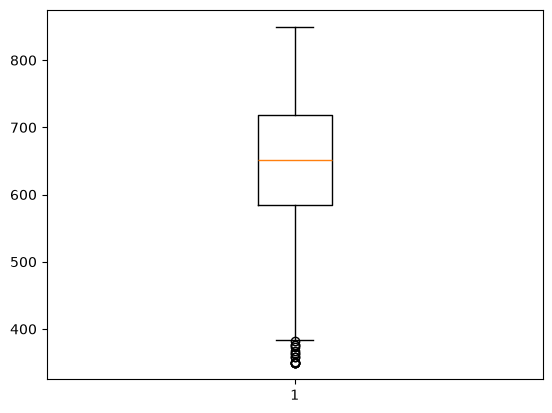

In [36]:
plt.boxplot(df["CreditScore"])
plt.show()

In [37]:
#Split data and to predict data
X = df.drop("Exited", axis=1)
y = df["Exited"]

In [38]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=67
)



In [39]:
scaler = RobustScaler()
ct = ColumnTransformer(
    transformers=[
        ('pass', 'passthrough', [ "HasCrCard", "IsActiveMember"]),
        ('encode', OneHotEncoder(drop="first",handle_unknown="ignore"), ['Geography',"Gender"])
    ],
    remainder=RobustScaler() # Keeps any columns not specified
)
ct.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pass', ...), ('encode', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",RobustScaler()
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fe

In [40]:

X_test= ct.transform(X_test)
X_train=ct.transform(X_train)
print(ct.get_feature_names_out())

['pass__HasCrCard' 'pass__IsActiveMember' 'encode__Geography_Germany'
 'encode__Geography_Spain' 'encode__Gender_Male' 'remainder__CreditScore'
 'remainder__Age' 'remainder__Tenure' 'remainder__Balance'
 'remainder__NumOfProducts' 'remainder__EstimatedSalary'
 'remainder__Satisfaction Score' 'remainder__Card Type'
 'remainder__Point Earned']


In [41]:
description = stats.describe(X_train, axis=0)
print("Means per column:", description.mean)
print("Variances per column:", description.variance)

Means per column: [ 0.703125    0.513625    0.2495      0.249875    0.546125   -0.00590038
  0.158625    0.00725    -0.16252901  0.532      -0.00245911  0.0078125
  0.2470625   0.00702296]
Variances per column: [0.20876633 0.24984559 0.18727316 0.18746092 0.24790347 0.52533302
 0.7701375  0.33256901 0.2399019  0.34026853 0.34290422 0.49765742
 0.3122179  0.33233397]


In [42]:
print(X_train.shape)
print(y_train.shape)

#Verify that there aren't anomalies
print(np.max(X_train), np.min(X_train))
print(np.max(y_train), np.min(y_train))


(8000, 14)
(8000,)
4.583333333333333 -2.263157894736842
1 0


In [43]:
for i in range(X_train.shape[1]):
    col_max = np.max(X_train[:, i])
    col_min = np.min(X_train[:, i])
    
    print(ct.get_feature_names_out()[i], "min:", col_min, "max:", col_max)

pass__HasCrCard min: 0.0 max: 1.0
pass__IsActiveMember min: 0.0 max: 1.0
encode__Geography_Germany min: 0.0 max: 1.0
encode__Geography_Spain min: 0.0 max: 1.0
encode__Gender_Male min: 0.0 max: 1.0
remainder__CreditScore min: -2.263157894736842 max: 1.4962406015037595
remainder__Age min: -1.5833333333333333 max: 4.583333333333333
remainder__Tenure min: -1.0 max: 1.0
remainder__Balance min: -0.76086891836589 max: 1.2063287323635448
remainder__NumOfProducts min: 0.0 max: 3.0
remainder__EstimatedSalary min: -1.0218715240711151 max: 1.0175576906496826
remainder__Satisfaction Score min: -1.0 max: 1.0
remainder__Card Type min: -0.5 max: 1.0
remainder__Point Earned min: -1.2321428571428572 max: 1.0153061224489797


In [44]:

#####Manual logstic regression
def sigmoide(z):
    return 1 / (1 + np.exp(-z))
registries, qualities = X_train.shape
n0 = np.sum(y_train == 0)
n1 = np.sum(y_train == 1)

w0 = registries / (2 * n0)
w1 = registries / (2 * n1)
cost_history = []
improvement=[]
b=0
theta = np.zeros(qualities)
lr = 0.05
i=0
epsilon = 1e-15
weights = np.where(y_train == 1, w1, w0)
while True:
    
    y_pred = X_train @ theta + b
    y_pred_normalized= sigmoide(y_pred)
    
    y_pred_normalized = np.clip(y_pred_normalized, epsilon, 1-epsilon)
    #entriopia causada / Log loss
    L = -np.sum(
    weights * (
        y_train * np.log(y_pred_normalized) +
        (1 - y_train) * np.log(1 - y_pred_normalized)
    )
    ) / registries
    #print(L)
    
    cost_history.append(L)
    diff = cost_history[i-1] - cost_history[i]
    improvement.append(diff)
    if i!=0 and abs(diff) < 1e-8:
        break
    #print(f"Iter {i}: costo={cost:.2e}")
    error= weights*( y_pred_normalized-y_train)
    dtheta =  (X_train.T @ error)/(registries)
    db =  np.sum(error)/(registries)
    #print(np.max(np.abs(dtheta)))
    #print(np.linalg.norm(dtheta))
    
    theta -= lr * dtheta
    b -= lr * db
    i+=1
print(cost_history[-1])
print(i)

0.5791430858245141
2878


In [45]:
df["Exited"].value_counts(normalize=True)

Exited
0    0.7962
1    0.2038
Name: proportion, dtype: float64

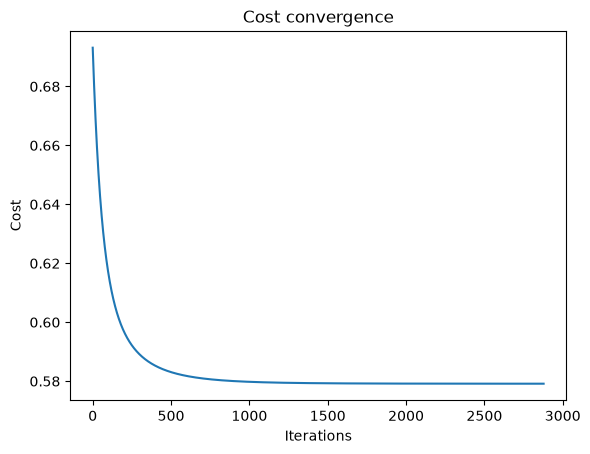

In [46]:
plt.plot(cost_history)
plt.title("Cost convergence")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()

In [47]:
###sklearn linear regression
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(
    
    class_weight="balanced",
    
)
modelo.fit(X_train,y_train)
y_pred= modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, 1]



In [48]:
##Comparison between differents threshholds
best_f1=0

for i in range(8):
    theshhold=(i*0.1)+0.1
    y_pred = (y_prob >= theshhold).astype(int)
    act_f1=f1_score(y_test,y_pred)
    if best_f1 < act_f1:
        print(f"{theshhold}-->{act_f1}")
        best_f1=act_f1

0.1-->0.34430379746835443
0.2-->0.37600377893245157
0.30000000000000004-->0.42393736017897093
0.4-->0.47441217150760717
0.5-->0.5021795989537925
0.6-->0.5095398428731762


In [49]:
##Sklearn prediction
theshhold=0.6
y_pred_sk = (y_prob >= theshhold).astype(int)


In [50]:
###Manual prediction

y_test_pred= sigmoide(theta@X_test.T+b)

y_test_pred = np.clip(y_test_pred, epsilon, 1-epsilon)


threshold=0.6
y_pred_manual=np.where(y_test_pred > threshold, 1, 0)

In [51]:
y_test_aux=y_test.T
print(y_pred)
y_test_list= list(y_test_aux)

[0 0 0 ... 1 0 0]


In [52]:
print(confusion_matrix(y_test,y_pred_sk))
print(accuracy_score(y_test,y_pred_sk))
print(precision_score(y_test,y_pred_sk))
print(recall_score(y_test,y_pred_sk))
print(f1_score(y_test,y_pred_sk))

[[1336  255]
 [ 182  227]]
0.7815
0.470954356846473
0.5550122249388753
0.5095398428731762


In [53]:
print(confusion_matrix(y_test,y_pred_manual))
print(accuracy_score(y_test,y_pred_manual))
print(precision_score(y_test,y_pred_manual))
print(recall_score(y_test,y_pred_manual))
print(f1_score(y_test,y_pred_manual))



[[1336  255]
 [ 181  228]]
0.782
0.4720496894409938
0.5574572127139364
0.5112107623318386
